In [25]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import pandas as pd, cvxpy as cp, numpy as np, matplotlib as mpl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

from matplotlib.ticker import FuncFormatter, MultipleLocator  # type: ignore
from matplotlib.patches import FancyArrowPatch, Polygon  # type: ignore
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from scipy.integrate import quad  # type: ignore
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d

import importlib, itertools, csv, concurrent.futures
import os, math, sys, json, pickle, shutil, time, functools

from typing import Dict, List, Any, Optional, Literal
from tqdm.notebook import tqdm

from Utils import Notebook, tex, gph, sgn, nm, ds
from Simulator import *
# from SimulatorOld import *
from optimization import DisturbedSaturatedPETC as DSPETC

cfg = {
    'style': {'color': 'black'},
    'axis': {
        'title_pad': 10,
        'x_label_fontsize': 16,
        'y_label_fontsize': 16,
        'tick_fontsize': 16,
    },
    'legend': {'fontsize': 16}
}

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


LaTeX has been enabled for text rendering.


### Definição da Planta

In [26]:
experiment_filename = 'exp-03'

with open(f"experiment-datas/{experiment_filename}.json", encoding='utf-8') as f:
  config = json.load(f)

plant = ds.StateSpace(data=config["plant"], name='plant')
latex_expr = plant.get_latex_equations()
print("Equações que regem a dinâmica da planta:")
tex.display_latex(latex_expr)

Equações que regem a dinâmica da planta:


<IPython.core.display.Latex object>

### Simulação da Planta em Malha Aberta

In [27]:
import Simulator
import matplotlib.pyplot as plt

# Parâmetros
experiment_file = f"experiment-datas/{experiment_filename}.json"
x0 = [0.1, -0.5]

y_hist, t_hist, u_hist = Simulator.open_loop(
    x0, experiment_file, u_constant=0.0)

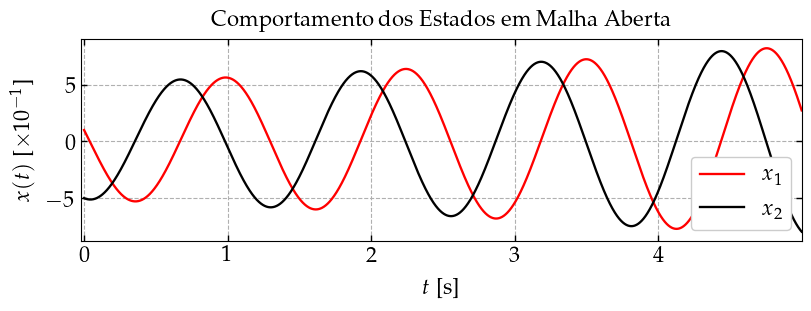

In [28]:
fig = plt.figure(figsize=(8, 3), layout='constrained')
axs = fig.subplot_mosaic([["x"]])

_ = gph.plot(
    axs['x'], t_hist, y_hist,
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=r'$x(t)$', color=['red', 'black'],
    label=[fr'$x_1$', fr'$x_2$'],
    cfg=cfg, title='Comportamento dos Estados em Malha Aberta',
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

### Projeto do Controlador e do ETM

In [29]:
def solve_problem(
    h: float,
    υ: float,
    eps: float = 1e-6,
):
  n_x = plant.nx
  n_u = plant.nu

  Onx = np.zeros((n_x, n_x))

  matrices = plant.evaluate_matrices(None, None, None)
  A = matrices['A']
  B = matrices['B']

  e = nm.get_e(5 * [n_x])

  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i], name=f"e{i}")

  constraints = []

  Ptil = cp.Variable((n_x, n_x), PSD=True)
  Mtil = cp.Variable((2 * n_x, 2 * n_x), PSD=True)
  Q1til = cp.Variable((n_x, n_x), symmetric=True)
  Q2til = cp.Variable((n_x, n_x))
  Q3til = cp.Variable((n_x, n_x))
  S1til = cp.Variable((n_x, n_x), symmetric=True)
  S2til = cp.Variable((n_x, n_x))
  S3til = cp.Variable((n_x, n_x))
  Ktil = cp.Variable((n_u, n_x))
  # Ktil = cp.Parameter((n_u, n_x), value=np.array([[1, -3.0]]))

  Rtil = cp.Variable((n_x, n_x), PSD=True)
  Ξtil = cp.Variable((n_x, n_x), PSD=True)
  Ψtil = cp.Variable((n_x, n_x), PSD=True)

  X = cp.Variable((n_x, n_x))
  Ytil = cp.Variable((2 * n_x, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx],
                  [Onx, 3. * Rtil]])

  Fscr = e[1].T + υ * e[2].T + υ * e[4].T

  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]],
                [e[1] + e[2] - 2. * e[3]]])

  def get_Θ(ω):
    Bscr = A @ X @ e[1] + B @ Ktil @ e[2] + + \
        B @ Ktil @ e[5] - X @ e[4]
    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]
    return nm.He(e[1].T @ Ptil @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil @ e[5] - \
        Θ1 - ω * Θ2 - h * e[3].T @ Q1til @ e[3] + \
        (h - ω) * Θ3 + (h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + (h - ω) * Θ4

  def get_Λ():
    Γ1_11 = get_Θ(0)
    Γ1_12 = e[2].T @ X.T

    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θ(h)
    Γ2_12 = Ytil.T
    Γ2_13 = e[2].T @ X.T

    Γ2_21 = Γ2_12.T
    Γ2_22 = - (1. / h) * Rcal
    Γ2_23 = np.zeros((2 * n_x, n_x))

    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  Γ1, Γ2 = get_Λ()
  constraints += [Γ1 << -eps * np.eye(Γ1.shape[0])]
  constraints += [Γ2 << -eps * np.eye(Γ2.shape[0])]

  constraints += [Ψtil >> eps * np.eye(n_x)]
  constraints += [Ξtil >> eps * np.eye(n_x)]

  obj = cp.Minimize(cp.trace(Ξtil + Ψtil))
  prob = cp.Problem(obj, constraints)

  # Solve the problem using the MOSEK solver
  prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

  # Initialize variables to store results
  design_results = None

  # Display the results
  if prob.status not in ["infeasible", "unbounded"]:
    Xinv = np.linalg.inv(X.value)
    Ξ = Xinv.T @ Ξtil.value @ Xinv
    Ψ = np.linalg.inv(Ψtil.value)
    P = Xinv.T @ Ptil.value @ Xinv
    S2 = Xinv.T @ S2til.value @ Xinv
    K = Ktil.value @ Xinv
    etm_results = {'Ξ': Ξ, 'Ψ': Ψ}
    design_results = {
        'optimal_value': prob.value,
        'etm': etm_results,
        'controller': {'K': K},
        'lyapunov': [P, S2],
    }
  else:
    design_results = None

  return design_results

In [30]:
sampling_period = config["design_params"]['h']
υ = 1e-1

prob_results = solve_problem(h=sampling_period, υ=υ)

if prob_results is not None:
  Ξ, Ψ = prob_results['etm']['Ξ'], prob_results['etm']['Ψ']
  K = prob_results['controller']['K']
  P, S2 = prob_results['lyapunov']

  display(Math(rf'\Xi = {tex.mat2tex(Ξ)}'))
  display(Math(rf'\Psi = {tex.mat2tex(Ψ)}'))
  display(Math(rf'P = {tex.mat2tex(P)}'))

  display(Math(rf'K = {tex.mat2tex(K)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [31]:
y_hist, t_hist, u_hist, events = closed_loop_setm(
    x0, experiment_file, prob_results)

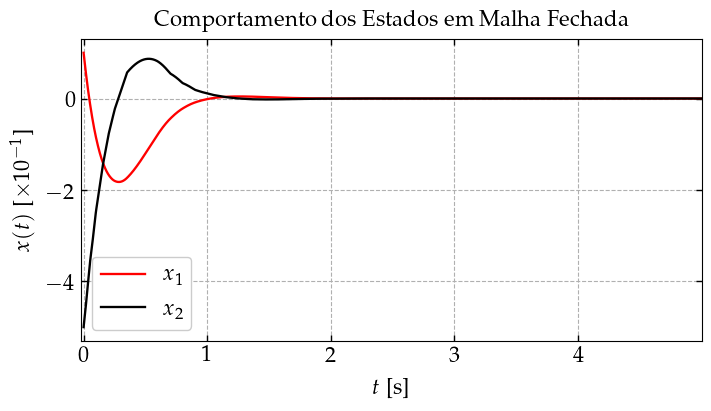

In [32]:
fig = plt.figure(figsize=(7, 4), layout='constrained')
axs = fig.subplot_mosaic([["x"]])

_ = gph.plot(
    axs['x'], t_hist, y_hist,
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=r'$x(t)$', color=['red', 'black'],
    label=[fr'$x_1$', fr'$x_2$'],
    cfg=cfg, title='Comportamento dos Estados em Malha Fechada',
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

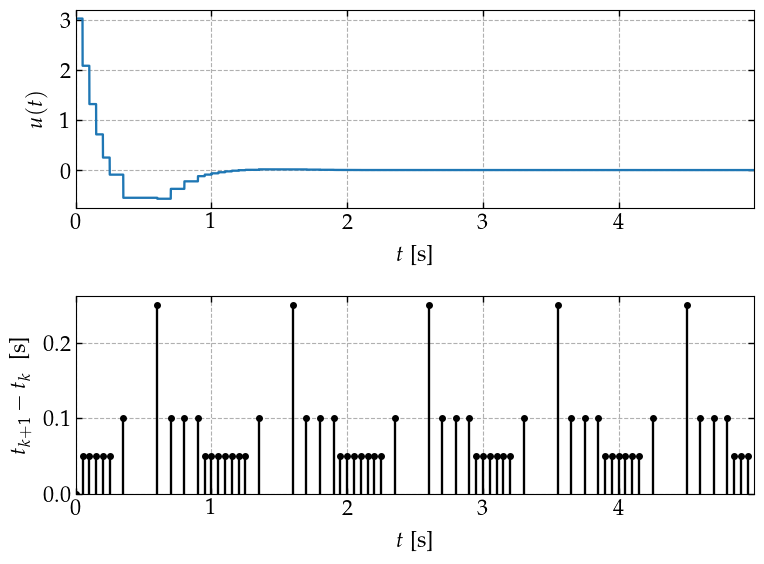

In [33]:
mosaic = [['control'], ['iet']]
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 6))

inter_event_times = nm.compute_deltas(events)

for i in range(plant.nu):
  gph.plot(
      axs['control'], t_hist, u_hist, xlabel='$t$', x_unit='s', x_use_prefixes=True,
      ylabel=r'$u(t)$', y_pad=(0.05, 0.05),
      cfg={**cfg, 'style': {'color': colors_list[0], "linestyle": ["-"], }},)

gph.stem(
    axs['iet'], events, inter_event_times,
    reuse_previous=False, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, t_hist[-1]),
    ylabel='$t_{k+1} - t_k\\;$', y_unit='s', y_use_prefixes=True,
    cfg={**cfg, 'limits': {'x_min': 0, 'x_max': t_hist[-1]}})

plt.tight_layout(pad=2.)

In [ ]:
import numpy as np
import networkx as nx
import tempfile
import shutil
import os
import gc
from joblib import Parallel, delayed, dump, load, cpu_count

# Certifique-se de que 'recurrence_model' e 'nm' estejam importados ou definidos
# Se estiverem definidos no Notebook, o joblib (backend 'loky') geralmente consegue serializá-los.
# Caso ocorra erro de 'AttributeError', mova essas funções para um arquivo .py separado.


def projective_eps_net(eps):
  """
  Generates a uniform sampling of the projective space S^1.

  Args:
      eps (float): Precision parameter for the epsilon-net.

  Returns:
      tuple: (X, theta) where X contains Cartesian coordinates and theta angular values.
  """
  N = int(np.ceil(np.pi / eps))
  theta = np.linspace(0, np.pi, N, endpoint=False)
  X = np.vstack([np.cos(theta), np.sin(theta)]).T
  return X, theta


def _process_batch_mmap(states_batch, h, config, prob_results_path):
  """
  Worker function executed in parallel processes.

  Reads 'prob_results' from a memory-mapped file to avoid serialization overhead
  and excessive RAM usage on Windows.

  Args:
      states_batch (np.ndarray): Subset of initial states to process.
      h (float): Discretization time step.
      config (dict): System configuration parameters.
      prob_results_path (str): Path to the temporary .mmap file.

  Returns:
      list: A list of symbolic sequences (k_seq) for the batch.
  """
  # Carrega o objeto mapeado em memória (Read-Only).
  # O SO gerencia o cache de página, evitando duplicar dados na RAM.
  prob_results = load(prob_results_path, mmap_mode='r')

  batch_results = []

  for x0 in states_batch:
    # Execução do modelo numérico
    event_times = recurrence_model(x0, config, prob_results)

    # Cálculo dos intervalos (assumindo nm importado externamente)
    inter_event_times = nm.compute_deltas(event_times[1:])

    # Discretização simbólica
    k_seq = [int(round(t / h)) for t in inter_event_times]
    batch_results.append(k_seq)

  return batch_results


def build_symbolic_graph_robust(l, eps, config, prob_results, n_jobs=-1):
  """
  Constructs a symbolic directed graph using optimized parallel processing for Windows.

  Implements:
  1. Memory Mapping (mmap) for large read-only data (prob_results).
  2. Batch processing to minimize IPC (Inter-Process Communication) overhead.
  3. Robust cleanup of temporary files to prevent disk clutter.

  Args:
      l (int): Word length for symbolic state representation.
      eps (float): Sampling density.
      config (dict): Configuration dictionary.
      prob_results (object): Heavy data object (e.g., probability matrix/solver results).
      n_jobs (int): Number of parallel jobs (-1 uses all CPUs).

  Returns:
      tuple: (G, initial_states) - The NetworkX DiGraph and sampled states.
  """
  h = config["design_params"]["h"]
  initial_states, _ = projective_eps_net(eps)
  G = nx.DiGraph()

  # 1. Configuração do ambiente temporário para mmap
  temp_dir = tempfile.mkdtemp()
  prob_results_path = os.path.join(temp_dir, 'prob_results.mmap')

  try:
    # Persiste o objeto pesado no disco para compartilhamento via memória
    dump(prob_results, prob_results_path)

    # 2. Definição da estratégia de Batching
    if n_jobs < 0:
      n_jobs = cpu_count()

    # Divide os estados em N chunks, onde N é o número de workers.
    # Isso garante que cada worker receba apenas uma grande tarefa.
    chunks = np.array_split(initial_states, n_jobs)

    # 3. Execução Paralela
    # Envia apenas o caminho do arquivo (str), não o objeto.
    results_nested = Parallel(n_jobs=n_jobs)(
        delayed(_process_batch_mmap)(chunk, h, config, prob_results_path)
        for chunk in chunks
    )

  finally:
    # 4. Limpeza Crítica (Windows File Locking Workaround)
    # Força a coleta de lixo para liberar handles de arquivos abertos pelos workers
    gc.collect()

    try:
      shutil.rmtree(temp_dir)
    except OSError as e:
      # Em Windows, o sistema de arquivos pode reter o lock por alguns milissegundos
      # mesmo após o fim do processo. O aviso é registrado mas não interrompe o fluxo.
      print(
          f"[Warning] Could not immediately clean temp files at {temp_dir}: {e}")

  # 5. Agregação e Construção do Grafo (Serial)
  # Flattening da lista de listas
  all_k_seqs = [seq for batch in results_nested for seq in batch]

  for k_seq in all_k_seqs:
    if len(k_seq) > l:
      # Janela deslizante para definição de arestas
      for i in range(len(k_seq) - l):
        state_curr = tuple(k_seq[i: i + l])
        state_next = tuple(k_seq[i + 1: i + l + 1])
        k_out = state_curr[0]

        G.add_edge(
            state_curr,
            state_next,
            weight=k_out,
            label=str(k_out)
        )

  return G, initial_states


# --- Exemplo de Uso ---
if __name__ == "__main__":
  # Parâmetros
  l = 6
  eps = 1e-3

  # Execução otimizada
  G_sampled, initial_states = build_symbolic_graph_robust(
      l=l,
      eps=eps,
      config=config,
      prob_results=prob_results,
      n_jobs=-1  # Usa todos os núcleos lógicos
  )

  print(
      f"Grafo construído com {G_sampled.number_of_nodes()} nós e {G_sampled.number_of_edges()} arestas.")

In [ ]:
import networkx as nx
from pyvis.network import Network


def visualize_sequence_in_graph(G, sequence=None, filename="symbolic_graph.html"):
  """
  G: grafo NetworkX
  sequence: lista de estados [s1, s2, s3, ...] que representa a trajetória desejada
  """
  net = Network(notebook=True, directed=True, width="100%", height="95vh")

  sccs = list(nx.strongly_connected_components(G))
  attractor_nodes = set()
  for scc in sccs:
    if len(scc) > 1:
      attractor_nodes.update(scc)
    else:
      node = next(iter(scc))
      if G.has_edge(node, node):
        attractor_nodes.add(node)

  node_id_map = {node: str(i) for i, node in enumerate(G.nodes)}

  for node, node_id in node_id_map.items():
    if sequence and node in sequence:
      color = "#00BFFF"
    elif node in attractor_nodes:
      color = "#FF8C00"
    else:
      color = "#97c2fc"

    net.add_node(
        node_id,
        label=str(node),
        title=f"Symbolic state {node}",
        shape="circle",
        size=35,
        color=color,
        font={"size": 16, "face": "Arial", "align": "center"},
    )

  for u, v, data in G.edges(data=True):
    u_id = node_id_map[u]
    v_id = node_id_map[v]
    weight = data.get("weight")

    is_in_sequence = False
    if sequence:
      for i in range(len(sequence) - 1):
        if u == sequence[i] and v == sequence[i + 1]:
          is_in_sequence = True
          break

    if is_in_sequence:
      edge_color = "#FF00FF"
      width = 3
    elif u in attractor_nodes and v in attractor_nodes:
      edge_color = "#FF4500"
      width = 2
    else:
      edge_color = "#888"
      width = 1

    if weight is not None:
      net.add_edge(u_id, v_id, label=str(weight), title=str(weight),
                   color=edge_color, width=width)
    else:
      net.add_edge(u_id, v_id, color=edge_color, width=width)

  net.force_atlas_2based(
      gravity=-50, central_gravity=0.01, spring_length=100)

  net.show(filename)


_seq = tuple(int(round(t / config['design_params']['h']))
             for t in inter_event_times)
sequence_pairs = [(_seq[i], _seq[i+1])
                  for i in range(len(_seq)-1)]

visualize_sequence_in_graph(G_sampled, sequence_pairs, "sampled_model.html")

In [ ]:
import numpy as np
from scipy.signal import cont2discrete
from z3 import Solver, Real, sat, Q, Or, And
from fractions import Fraction as PyFraction


def to_z3_rational(matrix):
  """
  Converte matrizes para o formato racional do Z3 para evitar erros de 
  arredondamento e garantir precisão analítica.
  """
  res = []
  for row in matrix:
    res_row = []
    for val in row:
      f = PyFraction(float(val)).limit_denominator(10**12)
      res_row.append(Q(f.numerator, f.denominator))
    res.append(res_row)
  return res


def solve_x0_absolute_certainty_v2(sequence, A_c, B_c, K, Xi, Psi, h, iet_max):
  """
  Inversor exato incorporando a condição de timeout (iet_max).
  Garante satisfatibilidade lógica para o modelo SETM com limite temporal.
  """
  nx = A_c.shape[0]
  m_max_steps = int(round(iet_max / h))

  # 1. Discretização ZOH
  sys_d = cont2discrete((A_c, B_c, np.zeros((1, nx)),
                        np.zeros((1, B_c.shape[1]))), h, method='zoh')
  Ad, Bd = sys_d[0], sys_d[1]

  def get_phi_m_np(m):
    """Calcula o operador de transição Phi(m)."""
    sum_ad = np.zeros_like(Ad)
    for p in range(m):
      sum_ad += np.linalg.matrix_power(Ad, p)
    return np.linalg.matrix_power(Ad, m) + sum_ad @ Bd @ K

  # 2. Setup do Solver
  solver = Solver()
  x0 = [Real(f'x0_{i}') for i in range(nx)]

  # Restrição de exclusão da solução nula
  solver.add(sum([v**2 for v in x0]) >= Q(1, 100))

  g_acc_np = np.eye(nx)

  for m_i in sequence:
    if m_i > m_max_steps:
      raise ArithmeticError(
          f"Sequência impossível: m_i ({m_i}) excede iet_max_steps ({m_max_steps})")

    for j in range(1, m_i + 1):
      # Cálculo da matriz de gatilho M_j
      phi_j = get_phi_m_np(j)
      I = np.eye(nx)
      M_j = phi_j.T @ Psi @ phi_j - (I - phi_j).T @ Xi @ (I - phi_j)

      # Projeção retroativa e simetrização
      M_p_np = 0.5 * (g_acc_np.T @ M_j @ g_acc_np +
                      (g_acc_np.T @ M_j @ g_acc_np).T)
      M_p_z3 = to_z3_rational(M_p_np)

      # Expressão simbólica da forma quadrática
      quad_form = sum(x0[r] * M_p_z3[r][c] * x0[c]
                      for r in range(nx) for c in range(nx))

      if j < m_i:
        # Condição obrigatória: Não pode ter disparado antes de m_i
        # Isso implica que a condição quadrática era >= 0
        solver.add(quad_form >= 0)
      else:
        # Instante j = m_i
        if m_i < m_max_steps:
          # O disparo ocorreu OBRIGATORIAMENTE pela condição quadrática
          solver.add(quad_form < 0)
        else:
          # m_i == m_max_steps: O disparo ocorreu por timeout.
          # A condição quadrática é irrelevante aqui (pode ser >= 0 ou < 0).
          # Não adicionamos restrição para permitir qualquer estado que não tenha disparado antes.
          pass

    # Evolução do estado acumulado para o próximo evento
    g_acc_np = get_phi_m_np(m_i) @ g_acc_np

  # 3. Verificação de Satisfatibilidade
  if solver.check() == sat:
    model = solver.model()
    return np.array([float(model[v].as_fraction()) for v in x0])
  else:
    raise ArithmeticError(
        "Inviabilidade Lógica: A sequência é matematicamente impossível para este sistema.")

In [ ]:
import itertools
import networkx as nx
import numpy as np


def build_symbolic_graph_z3_verified(l, K_set, h, A, B, K, Xi, Psi, iet_max):
  """
  Constrói o grafo simbólico l-completo usando o Z3 para garantir
  certeza absoluta na viabilidade de nós e transições.
  """
  # 1. Identificação de nós viáveis (Comprimento l)
  candidate_words = list(itertools.product(K_set, repeat=l))
  feasible_nodes = []

  print(f"=== [Z3] Validando {len(candidate_words)} nós (tam: {l}) ===")
  for word in candidate_words:
    try:
      # Se o Z3 encontrar um x0, o nó é fisicamente possível
      solve_x0_absolute_certainty_v2(word, A, B, K, Xi, Psi, h, iet_max)
      feasible_nodes.append(word)
    except ArithmeticError:
      continue

  G = nx.DiGraph()
  G.add_nodes_from(feasible_nodes)

  # 2. Validação de Transições (União sigma_1 U sigma_2 -> tam: l+1)
  print(f"=== [Z3] Validando transições (tam: {l+1}) ===")
  count_edges = 0
  for node_a in feasible_nodes:
    suffix = node_a[1:]
    for k_next in K_set:
      node_b = suffix + (k_next,)

      # Regra do dominó: o sufixo de A deve ser o prefixo de B
      if node_b in feasible_nodes:
        # A união é a sequência de node_a estendida pelo novo símbolo
        transition_sequence = node_a + (k_next,)

        try:
          # A aresta só existe se a sequência longa for SAT
          solve_x0_absolute_certainty_v2(
              transition_sequence, A, B, K, Xi, Psi, h, iet_max
          )
          G.add_edge(node_a, node_b,
                     weight=node_a[0], label=str(node_a[0]))
          count_edges += 1
        except ArithmeticError:
          # Caminho espúrio: individualmente possíveis, mas união impossível
          continue

  print("=== Relatório de Certeza Absoluta ===")
  print(f"Nós Verificados: {len(feasible_nodes)}")
  print(f"Arestas Reais:   {count_edges}")
  return G

In [ ]:
import scipy.linalg

l = 2
K_set = [1, 2, 3, 4, 5]
h = sampling_period

Ξ, Ψ = prob_results['etm']['Ξ'], prob_results['etm']['Ψ']
K = prob_results['controller']['K']

A, B, _, _ = plant.export_matrices_jit()

G_complete = build_symbolic_graph_z3_verified(
    l=l,
    K_set=K_set,
    h=h,
    A=A,
    B=B,
    K=K,
    Psi=Ψ,
    Xi=Ξ,
    iet_max=config["design_params"]['iet_max']
)

In [ ]:
visualize_sequence_in_graph(G_complete, sequence_pairs, "complete_model.html")

In [ ]:
set(G_sampled.edges()).issubset(set(G_complete.edges()))

In [ ]:
import random


def generate_sequence_from_graph(G, length, seed=None):
  """
  Gera uma sequência de símbolos k baseada em um passeio aleatório no grafo.

  Args:
      G (nx.DiGraph): Grafo simbólico onde os nós são tuplas de comprimento l.
      length (int): Comprimento total da sequência de símbolos desejada.
      seed (int, optional): Semente para reprodutibilidade.

  Returns:
      list: Sequência de inteiros k_i pertencente à linguagem do grafo.
  """
  if not G.nodes:
    raise ValueError(
        "O grafo está vazio. Não é possível gerar sequências.")

  if seed is not None:
    random.seed(seed)

  nodes = list(G.nodes)
  l_window = len(nodes[0])

  if length < l_window:
    # Retorna apenas o prefixo de um nó aleatório
    return list(random.choice(nodes)[:length])

  # Tentativa de gerar a sequência completa
  max_retries = 100
  for _ in range(max_retries):
    current_node = random.choice(nodes)
    sequence = list(current_node)

    while len(sequence) < length:
      successors = list(G.successors(current_node))

      if not successors:
        # Dead-end atingido: o grafo não é fortemente conexo neste ramo
        break

      # Seleciona o próximo nó e extrai o novo símbolo (último da tupla)
      current_node = random.choice(successors)
      sequence.append(current_node[-1])

    if len(sequence) == length:
      return sequence

  raise RuntimeError(
      "Não foi possível gerar uma sequência do comprimento desejado devido a dead-ends no grafo.")


# ============================================================
# Exemplo de uso
# ============================================================
seq_length = 20
my_seed = 10
sequence = generate_sequence_from_graph(G_sampled, seq_length, seed=my_seed)
print(f"Sequência gerada: {sequence}")

In [ ]:
# --- Exemplo de Uso ---
iet_max = config["design_params"]['iet_max']
n = 2
A, B, _, _ = plant.export_matrices_jit()
K = prob_results['controller']['K']
Ξ, Ψ = prob_results['etm']['Ξ'], prob_results['etm']['Ψ']
h = sampling_period
sequence = (2, 1, 1, 1, 1, 1, 1, 2)
try:
  x0_exact = solve_x0_absolute_certainty_v2(
      sequence, A, B, K, Ξ, Ψ, h, iet_max)
  x0_exact_norm = x0_exact / np.linalg.norm(x0_exact)
  print(f"Estado inicial normalizado: {x0_exact_norm}")
  x0 = np.array([[x0_exact_norm[0]], [x0_exact_norm[1]]], dtype=np.float32)
  _, _, _, events = closed_loop_setm(
      x0, config, prob_results)
  inter_event_times = nm.compute_deltas(events)

  print((inter_event_times / sampling_period)[1:len(sequence)+1])
except Exception as e:
  print(e)